## INSTALL

In [ ]:
import sys

REQUIRED_VERSION = (3, 11, 9)
current_version  = sys.version_info[:3]

if current_version != REQUIRED_VERSION:
    raise RuntimeError(
        f"Wrong Python version. Expected 3.11.9, "
        f"got {'.'.join(str(v) for v in current_version)}. "
        "Make sure the correct kernel is selected."
    )

print(f"Python {'.'.join(str(v) for v in current_version)} OK")

#%pip install torch torchvision --index-url https://download.pytorch.org/whl/cu124 --force-reinstall
#%pip install pandas numpy Pillow tqdm scikit-learn xgboost timm
%pip install timm lightgbm catboost seaborn

## IMPORTS

In [90]:
import os
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, TensorDataset
from PIL import Image
import tqdm
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.naive_bayes import GaussianNB
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import (
    StratifiedKFold, train_test_split,
    cross_val_score, ParameterGrid
)
from sklearn.metrics import (accuracy_score, f1_score, precision_score,
                             recall_score, confusion_matrix, classification_report)
import matplotlib.pyplot as plt
import seaborn as sns
import math
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from itertools import product
import warnings
from sklearn.exceptions import UndefinedMetricWarning
warnings.filterwarnings('ignore', category=UndefinedMetricWarning)
import open_clip

## MODEL SELECTOR

In [92]:
# we load the hugging face token to get fast download, make sure to create a .env file and put your token in there
with open('.env') as env_file:
    for env_line in env_file:
        if '=' in env_line and not env_line.startswith('#'):
            env_key, env_value = env_line.strip().split('=', 1)
            os.environ[env_key] = env_value

print('HF_TOKEN loaded' if os.environ.get('HF_TOKEN') else 'WARNING: HF_TOKEN not found in .env')

HF_TOKEN loaded


In [229]:
# --- Model Selector -----------------------------------------------------------
FEATURE_EXTRACTOR = 'dinov2' # use to have different models, for submission dinov2 is just better
USE_FINETUNED     = True   # True after running FINE-TUNING
N_FOLDS = 2 # Cross-validation folds (higher = more robust, but slower train times)
# -----------------------------------------------------------------------------

## DEFINITIONS

In [230]:
# =============================================================================
# DEVICE
# =============================================================================
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {device}')

# =============================================================================
# BACKBONE MODEL LOADING  (We are using DINOv2 ViT-g/14)
# =============================================================================

backbone_model = torch.hub.load('facebookresearch/dinov2', 'dinov2_vitg14')
backbone_model = backbone_model.to(device).eval()

backbone_preprocess = transforms.Compose([
    transforms.Resize(256, interpolation=transforms.InterpolationMode.BICUBIC),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

# The function that gets the embeddings from our backbone/core feature_extractor
def encode(batch):
    return backbone_model(batch.to(device)).float().cpu()

feature_file_suffix = '_dinov2'
print(f'Backbone: dinov2  |  suffix: {feature_file_suffix!r}  |  device: {device}')

# =============================================================================
# IMAGE SAVING HELPERS
# =============================================================================

def save_images(image_dir, output_file, has_labels=True):

    image_tensors = []
    labels        = []
    file_paths    = []

    if has_labels: # train set has labels
        
        # count the classes
        class_names    = sorted(os.listdir(image_dir))
        class_to_index = {name: i for i, name in enumerate(class_names)}
        total_images   = sum(
            len(os.listdir(os.path.join(image_dir, cls)))
            for cls in class_names
            if os.path.isdir(os.path.join(image_dir, cls))
        )
        
        count = 0
        
        # for each class
        for class_name in class_names:
            class_folder = os.path.join(image_dir, class_name)
            
            # for instance in class folder
            for filename in os.listdir(class_folder):
                
                # skip non images
                if not filename.lower().endswith(('.png')):
                    continue
                
                image_path = os.path.join(class_folder, filename)
                
                # open the image and convert to RGB (just incase, idk if supplied images in RGB mode), and use our model's preprocess function
                image_tensors.append(backbone_preprocess(Image.open(image_path).convert('RGB')))
                labels.append(class_to_index[class_name])
                
                file_paths.append(image_path)
                
                count += 1
                print(f'{count}/{total_images}', end='\r')
        
        # save images as one tensor file, makes it easier later
        torch.save({
            'tensors':        torch.stack(image_tensors),
            'labels':         torch.tensor(labels),
            'paths':          file_paths,
            'class_to_index': class_to_index,
        }, output_file)
        
    else: # test set has no assigned labels
        
        # count the images
        image_files  = [
            f for f in os.listdir(image_dir)
            if f.lower().endswith(('.jpg', '.jpeg', '.png'))
        ]
        total_images = len(image_files)
        
        # for each image
        for i, filename in enumerate(image_files, start=1):
            
            # open the image and convert to RGB (just incase, idk if supplied images in RGB mode), and use our model's preprocess function
            image_path = os.path.join(image_dir, filename)
            image_tensors.append(backbone_preprocess(Image.open(image_path).convert('RGB')))
            
            file_paths.append(image_path)
            
            print(f'{i}/{total_images}', end='\r')
        
        # save image as one tensor file
        torch.save({'tensors': torch.stack(image_tensors), 'paths': file_paths}, output_file)

    print(f'\nSaved {len(image_tensors)} images to {output_file}')

# This function passes every image through our backbone, and saves the feature/embedding vectors
def extract(input_file, output_file):
    
    # load our saved preprocessed images
    data         = torch.load(input_file, weights_only=False)
    images       = data['tensors']
    
    total_images = len(images)
    feature_list = []
    
    # set backbone model to pass forward mode
    with torch.no_grad():
        
        # for every image
        for i, image in enumerate(images, start=1):
            
            # pass image through model
            feature_list.append(encode(image.unsqueeze(0)).squeeze().numpy())
            print(f'{i}/{total_images}', end='\r')
    
    # save the features as one tensor
    features = np.array(feature_list)
    torch.save({**data, 'features': features}, output_file)
    
    print(f'\nExtracted {features.shape} -> saved to {output_file}')

Device: cuda


Using cache found in C:\Users\TheRe/.cache\torch\hub\facebookresearch_dinov2_main


Backbone: dinov2  |  suffix: '_dinov2'  |  device: cuda


In [231]:
# =============================================================================
# METRICS HELPER
# =============================================================================

# Return a dictionary of all the basic metrics
def compute_classification_metrics(true_labels, predicted_labels):
    
    # get number of classes, and number of instances in each class
    unique_classes, samples_per_class = np.unique(true_labels, return_counts=True)
    
    class_balance = {
        int(cls): round(100 * n / len(true_labels), 1)
        for cls, n in zip(unique_classes, samples_per_class)
    }
    
    return {
        'accuracy':      accuracy_score(true_labels, predicted_labels),
        'f1':            f1_score(true_labels, predicted_labels, average='weighted', zero_division=0),
        'precision':     precision_score(true_labels, predicted_labels, average='weighted', zero_division=0),
        'recall':        recall_score(true_labels, predicted_labels, average='weighted', zero_division=0),
        'class_balance': class_balance,
    }

# print the mean +/- std for each metric across all folds
def print_cross_validation_report(model_name, fold_metrics_list):

    print(f'--- {model_name} ---')
    for metric_name in ('accuracy', 'f1', 'precision', 'recall'):
        values     = [m[metric_name] for m in fold_metrics_list]
        mean_value = np.mean(values)
        std_value  = np.std(values)
        print(f'  {metric_name:<9}: {mean_value:.4f} +/- {std_value:.4f}')
    
    print('  class balance:')
    for cls, pct in fold_metrics_list[0]['class_balance'].items():
        print(f'    class {cls}: {pct}%')
    
    print()


# =============================================================================
# MLP MODEL
# =============================================================================

# A simple implementation of an MLP object, we can use different activations and layers and dropouts
class MLP(nn.Module):
    def __init__(self, input_size, num_classes, hidden_layers=(256, 128),
                 activation=nn.ReLU, dropout=0.0):
        
        super().__init__()
        network_layers     = []
        current_layer_size = input_size

        # construct the layers
        for layer_output_size in hidden_layers:
            network_layers.append(nn.Linear(current_layer_size, layer_output_size))
            network_layers.append(activation())
            
            if dropout > 0:
                network_layers.append(nn.Dropout(dropout))
            
            current_layer_size = layer_output_size

        # attach the output layer
        network_layers.append(nn.Linear(current_layer_size, num_classes))
        self.network = nn.Sequential(*network_layers)

    # parse input thru network
    def forward(self, input_tensor):
        return self.network(input_tensor)

# =============================================================================
# CLASSIFIER FUNCTIONS
# =============================================================================


def train_logistic_regression(training_features, training_labels,
                               validation_features, validation_labels,
                               regularisation_strength=1.0):
    
    model = LogisticRegression(C=regularisation_strength, max_iter=2000, random_state=42)
    model.fit(
        np.asarray(training_features, np.float64),
        np.asarray(training_labels,   np.int64)
    )
    predictions = model.predict(np.asarray(validation_features, np.float64))
    
    return model, compute_classification_metrics(validation_labels, predictions)


def train_support_vector_machine(training_features, training_labels,
                                  validation_features, validation_labels,
                                  kernel='rbf', regularisation_strength=1.0,
                                  gamma='scale'):
    model = SVC(
        kernel=kernel, C=regularisation_strength, gamma=gamma,
        decision_function_shape='ovr', random_state=42,
    )
    model.fit(
        np.asarray(training_features, np.float64),
        np.asarray(training_labels,   np.int64)
    )
    predictions = model.predict(np.asarray(validation_features, np.float64))
    
    return model, compute_classification_metrics(validation_labels, predictions)


def train_random_forest(training_features, training_labels,
                         validation_features, validation_labels,
                         number_of_trees=300):
    model = RandomForestClassifier(
        n_estimators=number_of_trees, max_features='sqrt', random_state=42, n_jobs=-1
    )
    model.fit(
        np.asarray(training_features, np.float64),
        np.asarray(training_labels,   np.int64)
    )
    predictions = model.predict(np.asarray(validation_features, np.float64))
    
    return model, compute_classification_metrics(validation_labels, predictions)


def train_xgboost_classifier(training_features, training_labels,
                              validation_features, validation_labels):
    model = XGBClassifier(
        objective='multi:softmax', eval_metric='mlogloss', verbosity=0, random_state=42,
    )
    model.fit(
        np.asarray(training_features, np.float64),
        np.asarray(training_labels,   np.int64)
    )
    predictions = model.predict(np.asarray(validation_features, np.float64))
    
    return model, compute_classification_metrics(validation_labels, predictions)

# Training of MLP, we use early stopping so we dont overfit and also to cut down training time
def train_multilayer_perceptron(training_features, training_labels,
                                 validation_features, validation_labels,
                                 hidden_layers=(256, 128), activation=nn.ReLU,
                                 dropout=0.0, epochs=200, learning_rate=1e-3):

    compute_device    = 'cuda' if torch.cuda.is_available() else 'cpu'
    number_of_classes = len(np.unique(training_labels))

    # Move data to tensors on the compute device
    training_input     = torch.tensor(np.asarray(training_features,   np.float32)).to(compute_device)
    training_targets   = torch.tensor(np.asarray(training_labels,     np.int64)).to(compute_device)
    validation_input   = torch.tensor(np.asarray(validation_features, np.float32)).to(compute_device)
    validation_targets = torch.tensor(np.asarray(validation_labels,   np.int64)).to(compute_device)

    # Create the loader
    training_data_loader = DataLoader(
        TensorDataset(training_input, training_targets),
        batch_size=512, shuffle=True
    )

    # Create the actual model with a set seed, optimiser and loss function
    torch.manual_seed(42)
    model         = MLP(training_input.shape[1], number_of_classes,
                        hidden_layers, activation, dropout).to(compute_device)
    optimizer     = torch.optim.Adam(model.parameters(), lr=learning_rate, weight_decay=1e-4)
    loss_function = nn.CrossEntropyLoss()

    # variables for early stopping
    best_val_loss              = float('inf')
    best_weights               = None
    epochs_without_improvement = 0

    # training loop
    for epoch in range(epochs):
        
        # Training pass
        model.train()
        for input_batch, target_batch in training_data_loader:
            optimizer.zero_grad()
            loss = loss_function(model(input_batch), target_batch)
            loss.backward()
            optimizer.step()

        # Validation check
        model.eval()
        with torch.no_grad():
            val_loss = loss_function(model(validation_input), validation_targets).item()

        # Save best weights and count how long we've been stuck
        if val_loss < best_val_loss:
            best_val_loss              = val_loss
            best_weights               = model.state_dict()
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1
            if epochs_without_improvement >= 25:
                break  # early stopping

    # get best weights
    model.load_state_dict(best_weights)
    model.eval()

    # get our predictions
    with torch.no_grad():
        predictions = model(validation_input).argmax(dim=1).cpu().numpy()

    return model, compute_classification_metrics(validation_labels, predictions)


def train_knn_classifier(training_features, training_labels,
                          validation_features, validation_labels,
                          number_of_neighbours=10, distance_metric='cosine'):
    # Cosine distance is the default because DINOv2/BioCLIP embeddings
    # live on a roughly hyper-spherical surface where cosine similarity works well.
    
    model = KNeighborsClassifier(
        n_neighbors=number_of_neighbours, metric=distance_metric, n_jobs=-1
    )
    model.fit(
        np.asarray(training_features, np.float64),
        np.asarray(training_labels,   np.int64)
    )
    predictions = model.predict(np.asarray(validation_features, np.float64))
    
    return model, compute_classification_metrics(validation_labels, predictions)

# =============================================================================
# SHARED PCA PIPELINE HELPER
# =============================================================================

# Fit a scaler and a PCA on train set, then apply them on test set 
def apply_scaler_and_pca(train_feat, val_feat, n_components):
    
    # Standardize
    scaler     = StandardScaler()
    train_feat = scaler.fit_transform(train_feat) # fit
    val_feat   = scaler.transform(val_feat) # apply

    # PCA
    pca        = PCA(n_components=n_components, svd_solver='auto')
    train_feat = pca.fit_transform(train_feat).astype(np.float32) # fit
    val_feat   = pca.transform(val_feat).astype(np.float32) # apply

    return train_feat, val_feat



In [232]:
# =============================================================================
# FINE-TUNE HELPER FUNCTIONS
# =============================================================================
# These are called by finetune() below.  Breaking them out keeps finetune()
# readable and makes each step easy to test or override independently.
# Fine-tuning applies to DINOv2 only; BioCLIP is always frozen.


def _freeze_and_unfreeze_backbone(backbone_model, num_blocks):
    """Freeze all backbone parameters, then unfreeze the last num_blocks
    DINOv2 transformer blocks plus the final norm layer.
    Returns (blocks, norm, num_blocks_used)."""
    for param in backbone_model.parameters():
        param.requires_grad = False

    blocks         = list(backbone_model.blocks)   # 40 transformer blocks
    norm           = backbone_model.norm
    default_blocks = 4   # DINOv2 paper recommendation

    if num_blocks is None:
        num_blocks = default_blocks

    for block in blocks[-num_blocks:]:
        for param in block.parameters():
            param.requires_grad = True
    for param in norm.parameters():
        param.requires_grad = True

    trainable = sum(p.numel() for p in backbone_model.parameters() if p.requires_grad)
    total     = sum(p.numel() for p in backbone_model.parameters())
    print(f'Trainable: {trainable:,}/{total:,} '
          f'({100*trainable/total:.1f}%)  '
          f'[{num_blocks}/{len(blocks)} blocks unfrozen]')

    return blocks, norm, num_blocks


def _build_prefix_and_suffix(backbone_model, blocks, norm, num_blocks):
    """Build two callables that split DINOv2 at the freeze boundary.

    frozen_prefix_fn(batch) -- patch-embed + frozen transformer blocks.
    trainable_suffix_fn(x)  -- unfrozen blocks + norm -> CLS token (B, 1536).
    """
    def frozen_prefix_fn(batch):
        x = backbone_model.prepare_tokens_with_masks(batch)
        for block in backbone_model.blocks[:-num_blocks]:
            x = block(x)
        return x

    def trainable_suffix_fn(x):
        for block in blocks[-num_blocks:]:
            x = block(x)
        x = norm(x)
        return x[:, 0]   # CLS token -> (B, 1536)

    return frozen_prefix_fn, trainable_suffix_fn


def _cache_frozen_activations(backbone_model, images, frozen_prefix_fn, batch_size, device):
    """Run every image through frozen_prefix_fn once; store in fp16.
    Returns the cached tensor of shape (N, seq_len, d_model)."""
    with torch.no_grad():
        sample_act = frozen_prefix_fn(images[:1].to(device))

    est_gb = sample_act.numel() * len(images) * 2 / 1e9
    print(f'Caching frozen activations (~{est_gb:.1f} GB in fp16)...')

    chunks = []
    backbone_model.eval()
    with torch.no_grad():
        for i in range(0, len(images), batch_size):
            chunk = frozen_prefix_fn(images[i:i+batch_size].to(device)).cpu().half()
            chunks.append(chunk)
            print(f'  {min(i+batch_size, len(images))}/{len(images)}', end='\r')

    frozen_cache = torch.cat(chunks)
    del chunks
    print(f'\n  Done. Cache shape: {tuple(frozen_cache.shape)}')
    return frozen_cache


def _extract_via_suffix(source, suffix_fn, use_cache, backbone_model, batch_size, device):
    """Push source through suffix_fn (or backbone_model when not caching).
    Returns a CPU tensor of shape (n_samples, feature_dim)."""
    chunks = []
    with torch.no_grad():
        for i in range(0, len(source), batch_size):
            chunk = source[i:i+batch_size].to(device=device, dtype=torch.float32)
            out   = suffix_fn(chunk) if use_cache else backbone_model(chunk)
            chunks.append(out.cpu())
    return torch.cat(chunks)


def _build_finetune_head(source_sample, suffix_fn, use_cache,
                         backbone_model, num_classes, dropout, device):
    """Infer feature dim via one forward pass, then build a 2-layer head."""
    with torch.no_grad():
        sample      = source_sample[:1].to(device).float()
        feature_dim = (suffix_fn(sample) if use_cache else backbone_model(sample)).shape[-1]
    return nn.Sequential(
        nn.Linear(feature_dim, 512), nn.GELU(), nn.Dropout(dropout),
        nn.Linear(512, num_classes),
    ).to(device)


def _run_finetune_training_loop(backbone_model, head, training_loader,
                                 val_source, labels, val_idx,
                                 suffix_fn, use_cache,
                                 optimizer, loss_fn, grad_scaler,
                                 batch_dtype, use_amp,
                                 device, batch_size, epochs, patience,
                                 trainable_param_names):
    """Train for up to epochs with early stopping; return best state dicts."""
    best_val_loss  = float('inf')
    best_bb_state  = None
    best_hd_state  = None
    no_improve     = 0

    for epoch in range(epochs):
        backbone_model.train()
        head.train()
        for input_batch, target_batch in training_loader:
            input_batch  = input_batch.to(device=device, dtype=batch_dtype)
            target_batch = target_batch.to(device)
            optimizer.zero_grad()
            with torch.autocast('cuda', enabled=use_amp):
                feats      = suffix_fn(input_batch) if use_cache else backbone_model(input_batch)
                batch_loss = loss_fn(head(feats), target_batch)
            grad_scaler.scale(batch_loss).backward()
            grad_scaler.step(optimizer)
            grad_scaler.update()

        backbone_model.eval()
        head.eval()
        val_feats = _extract_via_suffix(
            val_source, suffix_fn, use_cache, backbone_model, batch_size, device
        ).to(device)
        val_loss = loss_fn(head(val_feats), labels[val_idx].to(device)).item()
        print(f'Epoch {epoch+1:>3}/{epochs}  val_loss={val_loss:.4f}', end='\r')

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_bb_state = {
                k: v.cpu().clone()
                for k, v in backbone_model.state_dict().items()
                if k in trainable_param_names
            }
            best_hd_state = {k: v.cpu().clone() for k, v in head.state_dict().items()}
            no_improve = 0
        else:
            no_improve += 1
            if no_improve >= patience:
                print(f'\nEarly stopping at epoch {epoch+1}')
                break

    print(f'\nBest val_loss: {best_val_loss:.4f}')
    return best_bb_state, best_hd_state


# =============================================================================
# FINE-TUNE ENTRY POINT
# =============================================================================

def finetune(images_file, train_idx, val_idx, num_classes,
             num_blocks=None, backbone_lr=1e-5, head_lr=1e-3,
             dropout=0.1, epochs=20, batch_size=32,
             patience=5, should_cache_frozen_activations=True):
    """Fine-tune the last num_blocks DINOv2 transformer blocks.

    should_cache_frozen_activations=True  Pre-computes frozen activations once
        (~3 GB fp16), so each training step only runs the small unfrozen suffix
        (~5-10x faster).  Set False only if still OOM.
    num_blocks=None  Uses the DINOv2 default: 4 of 40 blocks.
    """
    print(f'Device: {device}  |  backbone: dinov2  (GPU strongly recommended)')

    data   = torch.load(images_file, weights_only=False, mmap=True)
    images = data['tensors']
    labels = data['labels']

    # Step 1: freeze backbone, unfreeze last num_blocks + norm
    blocks, norm, num_blocks = _freeze_and_unfreeze_backbone(backbone_model, num_blocks)

    # Step 2: build frozen-prefix and trainable-suffix callables
    frozen_prefix_fn, suffix_fn = _build_prefix_and_suffix(
        backbone_model, blocks, norm, num_blocks
    )

    # Step 3: optionally cache frozen activations
    if should_cache_frozen_activations:
        frozen_cache  = _cache_frozen_activations(
            backbone_model, images, frozen_prefix_fn, batch_size, device
        )
        del data, images
        train_dataset = TensorDataset(frozen_cache[train_idx], labels[train_idx])
        val_source    = frozen_cache[val_idx]
        source_sample = frozen_cache
    else:
        train_dataset = TensorDataset(images[train_idx], labels[train_idx])
        val_source    = images[val_idx]
        source_sample = images

    # Step 4: build classification head
    head = _build_finetune_head(
        source_sample, suffix_fn,
        use_cache      = should_cache_frozen_activations,
        backbone_model = backbone_model,
        num_classes    = num_classes,
        dropout        = dropout,
        device         = device,
    )

    # Step 5: optimizer and training utilities
    trainable_param_names = {
        name for name, p in backbone_model.named_parameters() if p.requires_grad
    }
    optimizer = torch.optim.AdamW([
        {'params': [p for p in backbone_model.parameters() if p.requires_grad],
         'lr': backbone_lr},
        {'params': head.parameters(), 'lr': head_lr},
    ], weight_decay=1e-4)

    use_amp      = (device == 'cuda')
    grad_scaler  = torch.amp.GradScaler('cuda', enabled=use_amp)
    batch_dtype  = torch.float16 if use_amp else torch.float32
    loss_fn      = nn.CrossEntropyLoss()
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

    # Step 6: training loop with early stopping
    best_bb_state, best_hd_state = _run_finetune_training_loop(
        backbone_model, head, train_loader,
        val_source, labels, val_idx,
        suffix_fn, use_cache = should_cache_frozen_activations,
        optimizer = optimizer, loss_fn = loss_fn,
        grad_scaler = grad_scaler, batch_dtype = batch_dtype, use_amp = use_amp,
        device = device, batch_size = batch_size, epochs = epochs,
        patience = patience, trainable_param_names = trainable_param_names,
    )

    # Step 7: restore best weights and get final predictions
    current_state = backbone_model.state_dict()
    current_state.update({k: v.to(device) for k, v in best_bb_state.items()})
    backbone_model.load_state_dict(current_state)
    head.load_state_dict({k: v.to(device) for k, v in best_hd_state.items()})

    backbone_model.eval()
    head.eval()
    val_preds = head(
        _extract_via_suffix(
            val_source, suffix_fn, should_cache_frozen_activations,
            backbone_model, batch_size, device
        ).to(device)
    ).argmax(dim=1).cpu().numpy()

    for param in backbone_model.parameters():
        param.requires_grad = False

    return head, compute_classification_metrics(labels[val_idx].numpy(), val_preds)

## FINE TUNING

In [ ]:
# =============================================================================
# FINE TUNING
# =============================================================================
# Re-trains the last few blocks of the backbone on the task 2
# training images, then extracts features with the updated backbone.
#
# YOU MUST: Run LOAD DATA first so the images tensor .pt file exists.
# 
# After this cell completes, set USE_FINETUNED = True in MODEL SELECTOR
# and re-run LOAD DATA so later cells use the fine-tuned features.

# our preprocessed images
_train_images_path = f'Data\\task2_data\\t2_train_images{feature_file_suffix}.pt'

if not os.path.exists(_train_images_path):
    raise FileNotFoundError(
        f'Images file not found: {_train_images_path}\n'
        'Run the LOAD DATA cell first.'
    )

# get number of classes
raw_images_pt      = torch.load(_train_images_path, weights_only=False)
num_classes        = len(np.unique(raw_images_pt['labels'].numpy()))
all_sample_indices = np.arange(len(raw_images_pt['labels']))

# 80/20 train/val split for fine-tuning (stratified)
finetune_train_idx, finetune_val_idx = train_test_split(
    all_sample_indices, test_size=0.2, random_state=42,
    stratify=raw_images_pt['labels'].numpy(),
)

fine_tuned_head, finetune_val_metrics = finetune(
    images_file                     = _train_images_path,
    train_idx                       = finetune_train_idx,
    val_idx                         = finetune_val_idx,
    num_classes                     = num_classes,
    num_blocks                      = 2,     # fewer blocks for this small dataset
    backbone_lr                     = 1e-6,
    head_lr                         = 1e-4,
    dropout                         = 0.2,
    epochs                          = 15,
    batch_size                      = 8,     # lower if VRAM is shit
    patience                        = 7,
    should_cache_frozen_activations = True,
)

# --- Extract features with the fine-tuned backbone -----------------------
# The saved _ft files are what USE_FINETUNED = True in MODEL SELECTOR loads.

print('\nExtracting features with fine-tuned backbone...')
extract(
    f'Data\\task2_data\\t2_train_images{feature_file_suffix}.pt',
    f'Data\\task2_data\\t2_train_features_ft{feature_file_suffix}.pt',
)
extract(
    f'Data\\task2_data\\t2_test_images{feature_file_suffix}.pt',
    f'Data\\task2_data\\t2_test_features_ft{feature_file_suffix}.pt',
)
print('Done.  Set USE_FINETUNED = True in MODEL SELECTOR and re-run LOAD DATA.')


Device: cuda  |  backbone: convnextv2  (GPU strongly recommended)
Trainable: 127,243,776/657,472,640 (19.4%)  [2/3 blocks unfrozen]
Caching frozen activations (~0.6 GB RAM in fp16)...
  417/417
  Done. Cache shape: (417, 2816, 16, 16)  (fp16)
Epoch  15/15  val_loss=0.0904
Best val_loss: 0.0881
Fine-tuned val:  F1=0.9404  Acc=0.9405

Re-extracting features with fine-tuned backbone...
417/417
Extracted (417, 2816) -> saved to Data\task2_data\t2_train_features_ft_convnextv2.pt
180/180
Extracted (180, 2816) -> saved to Data\task2_data\t2_test_features_ft_convnextv2.pt
Done.  Set USE_FINETUNED = True in MODEL SELECTOR to use these features.


## LOAD DATA

In [233]:
# =============================================================================
# LOAD DATA
# =============================================================================
# Saves images and extracts backbone features on first run, then loads from
# .pt cache files on every subsequent run.

train_image_dir = r'Data\task2_data\images\train'
test_image_dir  = r'Data\task2_data\images\test'

if not os.path.exists(train_image_dir):
    raise FileNotFoundError(f'Training folder not found: {train_image_dir}')
if not os.path.exists(test_image_dir):
    raise FileNotFoundError(f'Test folder not found: {test_image_dir}')


# --- Helper: build all .pt cache file paths ----------------------------------

# return a dict of all cache paths of the current config (what model and if finetuned)
def _build_data_paths(suffix, ft_tag):
    base = r'Data\task2_data\\'
    return {
        'train_images':  f'{base}t2_train_images{suffix}.pt',
        'test_images':   f'{base}t2_test_images{suffix}.pt',
        'train_feat':    f'{base}t2_train_features{ft_tag}{suffix}.pt',
        'test_feat':     f'{base}t2_test_features{ft_tag}{suffix}.pt',
        'bioclip_train': f'{base}t2_train_features_bioclip.pt',
        'bioclip_test':  f'{base}t2_test_features_bioclip.pt',
    }


# --- Helper: create DINOv2 image/feature caches if missing ------------------

# Function that ensures that our backbone model files exist, if they dont we create them
def _ensure_base_caches(paths):

    if not os.path.exists(paths['train_images']):
        save_images(train_image_dir, paths['train_images'], has_labels=True)
        
    if not os.path.exists(paths['test_images']):
        save_images(test_image_dir, paths['test_images'], has_labels=False)
        
    if not os.path.exists(paths['train_feat']):
        extract(paths['train_images'], paths['train_feat'])
        
    if not os.path.exists(paths['test_feat']):
        extract(paths['test_images'], paths['test_feat'])


# --- Helper: create BioCLIP feature caches if missing -----------------------

# Function that ensures that our helper model (BioCLIP) files exist, if they dont we create them
def _ensure_bioclip_caches(paths):

    # if both cache files already exist, nothing to do
    if os.path.exists(paths['bioclip_train']) and os.path.exists(paths['bioclip_test']):
        return

    print('BioCLIP features not found — extracting (runs once)...')

    # load BioCLIP model and its own preprocessor
    _bio_model, _, _bio_preprocess = open_clip.create_model_and_transforms(
        'hf-hub:imageomics/bioclip'
    )
    _bio_model = _bio_model.to(device).eval()

    # basically the same function as save_images() but specifically for bioclip
    def save_images_bioclip(image_dir, output_file, has_labels=True):

        image_tensors = []
        labels        = []
        file_paths    = []

        if has_labels: # train set has labels

            # count the classes
            class_names    = sorted(os.listdir(image_dir))
            class_to_index = {name: i for i, name in enumerate(class_names)}
            total_images   = sum(
                len(os.listdir(os.path.join(image_dir, cls)))
                for cls in class_names
                if os.path.isdir(os.path.join(image_dir, cls))
            )

            count = 0

            # for each class
            for class_name in class_names:
                class_folder = os.path.join(image_dir, class_name)

                # for instance in class folder
                for filename in os.listdir(class_folder):

                    # skip non images
                    if not filename.lower().endswith(('.png')):
                        continue

                    image_path = os.path.join(class_folder, filename)

                    # open the image and convert to RGB, use bioclip's own preprocess function
                    image_tensors.append(_bio_preprocess(Image.open(image_path).convert('RGB')))
                    labels.append(class_to_index[class_name])

                    file_paths.append(image_path)

                    count += 1
                    print(f'{count}/{total_images}', end='\r')

            # save images as one tensor file
            torch.save({
                'tensors':        torch.stack(image_tensors),
                'labels':         torch.tensor(labels),
                'paths':          file_paths,
                'class_to_index': class_to_index,
            }, output_file)

        else: # test set has no assigned labels

            # count the images
            image_files  = [
                f for f in os.listdir(image_dir)
                if f.lower().endswith(('.jpg', '.jpeg', '.png'))
            ]
            total_images = len(image_files)

            # for each image
            for i, filename in enumerate(image_files, start=1):

                # open the image and convert to RGB, use bioclip's own preprocess function
                image_path = os.path.join(image_dir, filename)
                image_tensors.append(_bio_preprocess(Image.open(image_path).convert('RGB')))

                file_paths.append(image_path)

                print(f'{i}/{total_images}', end='\r')

            # save image as one tensor file
            torch.save({'tensors': torch.stack(image_tensors), 'paths': file_paths}, output_file)

        print(f'\nSaved {len(image_tensors)} images to {output_file}')

    # basically the same function as extract() but specifically for bioclip
    def extract_bioclip(input_file, output_file):

        # load our saved preprocessed images
        data         = torch.load(input_file, weights_only=False)
        images       = data['tensors']

        total_images = len(images)
        feature_list = []

        # set bioclip model to forward pass mode
        with torch.no_grad():

            # for every image
            for i, image in enumerate(images, start=1):

                # pass image through bioclip's encode_image
                feats = _bio_model.encode_image(image.unsqueeze(0).to(device)).float().cpu()

                # normalise so all vectors have length 1, needed for cosine similarity
                feats = feats / feats.norm(dim=-1, keepdim=True)

                feature_list.append(feats.squeeze().numpy())
                print(f'{i}/{total_images}', end='\r')

        # save the features as one tensor
        features = np.array(feature_list)
        torch.save({**data, 'features': features}, output_file)

        print(f'\nExtracted {features.shape} -> saved to {output_file}')

    print('  BioCLIP train images...')
    save_images_bioclip(train_image_dir, paths['bioclip_train'], has_labels=True)

    print('  Extracting BioCLIP train features...')
    extract_bioclip(paths['bioclip_train'], paths['bioclip_train'])

    print('  BioCLIP test images...')
    save_images_bioclip(test_image_dir, paths['bioclip_test'], has_labels=False)

    print('  Extracting BioCLIP test features...')
    extract_bioclip(paths['bioclip_test'], paths['bioclip_test'])

    # free GPU memory if we using GPU, not sure why but for BIOclip my PC freaks out if we dont do this
    del _bio_model
    if device == 'cuda':
        torch.cuda.empty_cache()

    print('BioCLIP extraction complete.')
# =============================================================================
# Run the data pipeline
# =============================================================================

# are we using finetuned or not?
finetune_tag = '_ft' if USE_FINETUNED else ''
_paths       = _build_data_paths(feature_file_suffix, finetune_tag)

_ensure_base_caches(_paths)
_ensure_bioclip_caches(_paths)


# --- Load DINOv2 features ----------------------------------------------------

train_features_pt = torch.load(_paths['train_feat'], weights_only=False)
test_features_pt  = torch.load(_paths['test_feat'],  weights_only=False)

train_features    = train_features_pt['features']
train_labels      = train_features_pt['labels'].numpy()

test_features     = test_features_pt['features']
test_image_paths  = test_features_pt['paths']

# debug stuff
train_image_paths = train_features_pt['paths']
class_to_index    = train_features_pt['class_to_index']

index_to_class    = {v: k for k, v in class_to_index.items()}
num_classes       = len(class_to_index)

n_original = len(train_labels)   # kept for backward compatibility with other cells


# =============================================================================
# Train / val split on original images
# =============================================================================
# 80% training, 20% validation, stratified.

train_idx, val_idx = train_test_split(
    np.arange(n_original), test_size=0.2, random_state=42, stratify=train_labels
)

# Used by error analysis cell
base_train_idx = train_idx
base_val_idx   = val_idx

# Shared feature arrays used by HYPER PARAM SEARCH and ERROR ANALYSIS
backbone_train_features = np.asarray(train_features[train_idx], dtype=np.float32)
backbone_val_features   = np.asarray(train_features[val_idx],   dtype=np.float32)
backbone_train_labels   = train_labels[train_idx]
backbone_val_labels     = train_labels[val_idx]

base_train_labels    = train_labels[base_train_idx]
base_val_labels      = train_labels[base_val_idx]
base_val_image_paths = [train_image_paths[i] for i in base_val_idx]

print(f'Data     : {finetune_tag or "frozen"}, {feature_file_suffix}')
print(f'Features : {train_features.shape}  ({num_classes} classes)')
print(f'Classes  : {list(class_to_index.keys())}')
print(f'Train    : {len(train_idx)}   Val: {len(val_idx)}   Test: {len(test_features)}')

Data     : _ft, _dinov2
Features : (417, 1536)  (10 classes)
Classes  : ['American_Goldfinch', 'Blue_Jay', 'Cardinal', 'Herring_Gull', 'House_Sparrow', 'Red_winged_Blackbird', 'Ring_billed_Gull', 'Song_Sparrow', 'Wilson_Warbler', 'Yellow_Warbler']
Train    : 333   Val: 84   Test: 180


## CONCAT HYBRID MODEL
Concatenate DINOv2 and BioCLIP feature vectors into one wide vector,
optionally reduce with PCA, then train a single MLP classifier.

DINOv2 (1536-d) ++ BioCLIP (512-d) = 2048-d concat.
Fine-tuning applies to DINOv2 only; BioCLIP is always frozen.
Run LOAD DATA first.

Concat: 1536d (DINOv2) + 512d (BioCLIP) = 2048d  |  417 samples  |  10 classes
Fitting PCA(417) for variance plot...


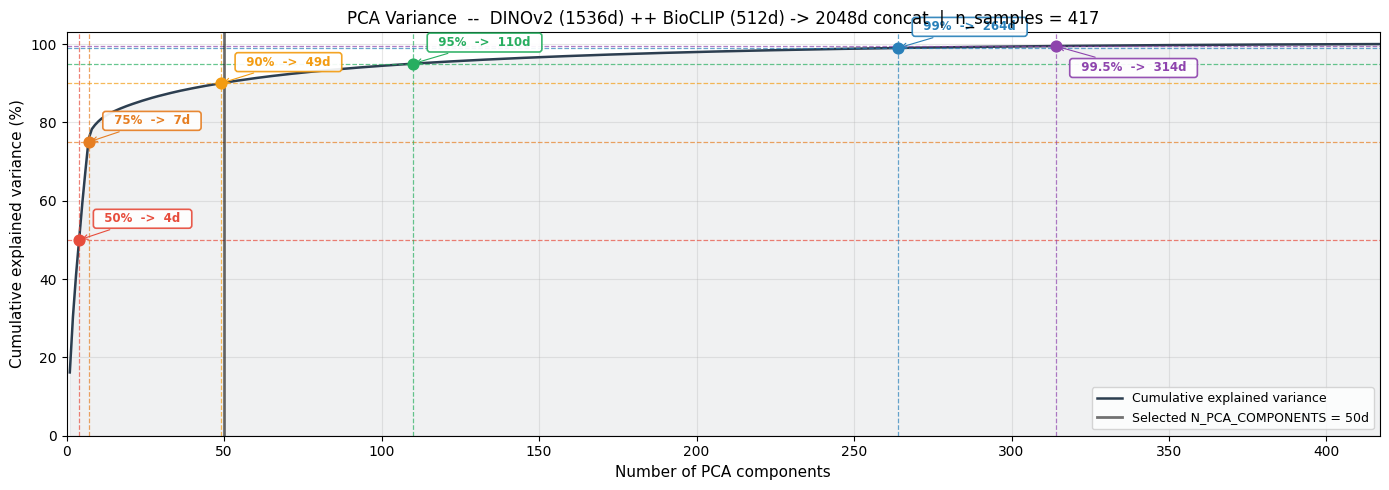

In [235]:
# =============================================================================
# CONCAT HYBRID MODEL: DINOv2 ++ BioCLIP -> (optional PCA) -> MLP
# =============================================================================
# Instead of training two separate classifiers, we concatenate the raw feature
# vectors from both backbones into one wide vector and feed a single MLP.
#
# DINOv2 (1536-d) ++ BioCLIP (512-d) = 2048-d
#
# Optionally we can apply StandardScaler + PCA to reduce dimensionality first.
# Scaler and PCA are fitted on fold-training data only.

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# --- Settings ----------------------------------------------------------------

USE_PCA          = True    # True: scale -> PCA -> MLP | False: raw 2048-d -> MLP
N_PCA_COMPONENTS = 50     # components to keep when USE_PCA=True, Also based on K_FOLDS so there is a trade off for robustness and PCA resolution

CONCAT_DINO_FINETUNED = False   # set True after running FINE-TUNING on DINOv2


# --- Helper: PCA variance curve (visualisation only) -------------------------

def plot_pca_variance_curve(features, title, n_pca_selected=None):
    """Plot cumulative explained variance vs PCA components.
    Annotates 50/75/90/95/99/99.5 % thresholds and draws a line at n_pca_selected."""
    max_components = min(features.shape)
    print(f'Fitting PCA({max_components}) for variance plot...')

    viz_scaler = StandardScaler()
    viz_scaled = viz_scaler.fit_transform(features)
    viz_pca    = PCA(n_components=max_components, svd_solver='full')
    viz_pca.fit(viz_scaled)
    cum_var = np.cumsum(viz_pca.explained_variance_ratio_) * 100

    thresholds = [
        (50,   '#E74C3C', +4.5),
        (75,   '#E67E22', +4.5),
        (90,   '#F39C12', +4.5),
        (95,   '#27AE60', +4.5),
        (99,   '#2980B9', +4.5),
        (99.5, '#8E44AD', -6.5),
    ]

    fig, ax = plt.subplots(figsize=(14, 5))
    ax.plot(np.arange(1, max_components + 1), cum_var, lw=1.8,
            color='#2C3E50', label='Cumulative explained variance')
    ax.fill_between(np.arange(1, max_components + 1), cum_var, alpha=0.07, color='#2C3E50')

    for pct, color, y_off in thresholds:
        n_at = int(np.searchsorted(cum_var, pct)) + 1
        if n_at > max_components:
            continue
        ax.axhline(pct, color=color, lw=0.9, ls='--', alpha=0.7)
        ax.axvline(n_at, color=color, lw=0.9, ls='--', alpha=0.7)
        ax.scatter([n_at], [pct], color=color, s=60, zorder=5)
        ax.annotate(
            f'  {pct}%  ->  {n_at}d  ',
            xy=(n_at, pct),
            xytext=(n_at + max(3, max_components * 0.013), pct + y_off),
            fontsize=8.5, color=color, fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.25', facecolor='white',
                      edgecolor=color, alpha=0.92, linewidth=1.2),
            arrowprops=dict(arrowstyle='->', color=color, lw=0.8),
        )

    if n_pca_selected is not None:
        ax.axvline(n_pca_selected, color='black', lw=2.0, ls='-', alpha=0.55,
                   label=f'Selected N_PCA_COMPONENTS = {n_pca_selected}d')

    ax.set_xlabel('Number of PCA components', fontsize=11)
    ax.set_ylabel('Cumulative explained variance (%)', fontsize=11)
    ax.set_title(title, fontsize=12)
    ax.set_xlim(0, max_components)
    ax.set_ylim(0, 103)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=9)
    plt.tight_layout()
    plt.savefig('pca_variance_concat.png', dpi=150, bbox_inches='tight')
    plt.show()



# load the base features
dino_finetune_tag = '_ft' if CONCAT_DINO_FINETUNED else ''


dino_features_pt = torch.load(
    f'Data\\task2_data\\t2_train_features{dino_finetune_tag}_{FEATURE_EXTRACTOR}.pt',
    weights_only=False,
)
bio_features_pt = torch.load(
    'Data\\task2_data\\t2_train_features_bioclip.pt',
    weights_only=False,
)

concat_labels = dino_features_pt['labels'].numpy()
dino_features = np.asarray(dino_features_pt['features'], dtype=np.float32)
bio_features  = np.asarray(bio_features_pt['features'],  dtype=np.float32)

# Stack both feature vectors into one wide vector per image
concat_features   = np.concatenate([dino_features, bio_features], axis=1)
num_classes       = len(np.unique(concat_labels))
total_feature_dim = concat_features.shape[1]

print(f'Concat: {dino_features.shape[1]}d (DINOv2) + {bio_features.shape[1]}d (BioCLIP) = '
      f'{total_feature_dim}d  |  {len(concat_labels)} samples  |  {num_classes} classes')


# --- PCA variance plot -------------------------------------------------------

plot_pca_variance_curve(
    concat_features,
    title=(f'PCA Variance  --  DINOv2 ({dino_features.shape[1]}d) ++ '
           f'BioCLIP ({bio_features.shape[1]}d) '
           f'-> {total_feature_dim}d concat  |  n_samples = {len(concat_labels)}'),
    n_pca_selected = N_PCA_COMPONENTS if USE_PCA else None,
)

## META-CLASSIFIER MODEL

In [236]:
# =============================================================================
# META-CLASSIFIER MODEL: DINOv2-proba + BioCLIP-proba + deltas -> meta-clf
# =============================================================================
# Instead of concatenating raw feature vectors, we train a small linear
# classifier on each model separately, collect their probability
# outputs, compute the per class delta, and then feed everything to a meta-
# classifier that learns which model to trust
#
# Method:
#   1. Get DINOv2 probs   (N_FOLDS-fold, no leakage)
#   2. Get BIOclip probs  (N_FOLDS-fold, no leakage)
#   3. abs_delta  = |dino_proba - bio_proba|
#   4. meta_features = [dino_probs, bio_probs, delta]
#   5. Meta-classifier fitted on meta_features

from sklearn.base import clone


# --- Settings ----------------------------------------------------------------

META_USE_FINETUNED_DINO  = True   # True after running FINE-TUNING on DINOv2
META_BASE_C              = 10.0    # LogReg C for the two base classifiers
META_N_FOLDS             = N_FOLDS # folds used for OOF base-proba generation

# the base classifier used to generate probabilities for both DINOv2 and BioCLIP arms
meta_base_classifier = LogisticRegression(C=META_BASE_C, max_iter=2000, random_state=42)

# --- Helpers -----------------------------------------------------------------

# Gets a model's prediction on the all inputs, using stratified N-folds
# Each fold fits base_model on fold-train only
def _oof_probs(features, labels, base_model, n_folds):

    kfold     = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=42)
    n_classes = len(np.unique(labels))
    oof       = np.zeros((len(labels), n_classes), dtype=np.float32)
    for tr_i, va_i in kfold.split(features, labels):
        m = clone(base_model)
        m.fit(features[tr_i], labels[tr_i])
        oof[va_i] = m.predict_proba(features[va_i])
    return oof

# Stack the probs of both models + deltas together
def build_meta_features(dino_probs, bio_probs):
    delta = abs(dino_probs - bio_probs)
    return np.column_stack([dino_probs, bio_probs, delta])



# --- Load features -----------------------------------------------------------

dino_filename_tag = '_ft' if META_USE_FINETUNED_DINO else ''

dino_data = torch.load(
    f'Data\\task2_data\\t2_train_features{dino_filename_tag}_{FEATURE_EXTRACTOR}.pt',
    weights_only=False,
)
bio_data = torch.load(
    'Data\\task2_data\\t2_train_features_bioclip.pt',
    weights_only=False,
)

all_labels        = np.asarray(dino_data['labels'])
all_dino_features = np.asarray(dino_data['features'], dtype=np.float32)
all_bio_features  = np.asarray(bio_data['features'],  dtype=np.float32)

# restrict to the train / val split created in LOAD DATA
dino_train_features = all_dino_features[train_idx]
dino_val_features   = all_dino_features[val_idx]

bio_train_features  = all_bio_features[train_idx]
bio_val_features    = all_bio_features[val_idx]

meta_train_labels   = all_labels[train_idx]
meta_val_labels     = all_labels[val_idx]

n_classes_meta = len(np.unique(meta_train_labels))

print(f'DINOv2  train={dino_train_features.shape}  val={dino_val_features.shape}')
print(f'BioCLIP train={bio_train_features.shape}   val={bio_val_features.shape}')
print(f'Classes: {n_classes_meta}  ->  meta feature width = {3 * n_classes_meta}')


# --- OOF base probabilities on train set -------------------------------------

print(f'\nOOF base probs — DINOv2  ({META_N_FOLDS}-fold)...')
dino_oof_probs = _oof_probs(dino_train_features, meta_train_labels,
                             meta_base_classifier, META_N_FOLDS)

print(f'OOF base probs — BioCLIP ({META_N_FOLDS}-fold)...')
bio_oof_probs  = _oof_probs(bio_train_features,  meta_train_labels,
                             meta_base_classifier, META_N_FOLDS)

# --- Build meta features -----------------------------------------------------

# these are the inputs the meta-classifier will be trained on (done in hyperparameter search)
meta_train_features = build_meta_features(dino_oof_probs, bio_oof_probs)
print(f'\nMeta-train features: {meta_train_features.shape}  '
      f'[{n_classes_meta}d DINOv2 probs, '
      f'{n_classes_meta}d BioCLIP probs, '
      f'{n_classes_meta}d delta]')

DINOv2  train=(333, 1536)  val=(84, 1536)
BioCLIP train=(333, 512)   val=(84, 512)
Classes: 10  ->  meta feature width = 30

OOF base probs — DINOv2  (2-fold)...
OOF base probs — BioCLIP (2-fold)...

Meta-train features: (333, 30)  [10d DINOv2 probs, 10d BioCLIP probs, 10d delta]


## HYPER PARAM SEARCH

In [245]:
# =============================================================================
# UNIFIED HYPERPARAMETER SEARCH
# =============================================================================
# Evaluates every candidate with N_FOLDS-fold stratified cross-validation.
# StandardScaler + PCA (when enabled) fitted only on fold-train data, so
# there is no information leakage between folds.
#
# YOU MUST:
#   SEARCH_BACKBONE -> run LOAD DATA first
#   SEARCH_CONCAT   -> run CONCAT HYBRID MODEL first
#   SEARCH_META     -> run META-CLASSIFIER MODEL first

from sklearn.base import clone   # clone() makes a fresh unfitted copy per fold

# What to search over
SEARCH_BACKBONE = False   # single DINOv2 features
SEARCH_CONCAT   = True    # raw or PCA-reduced DINOv2+BioCLIP concat features
SEARCH_META     = False   # meta-classifier (base LogReg on DINOv2+BioCLIP -> meta model)

# PCA settings for concat search (only used when SEARCH_CONCAT = True)
CONCAT_SEARCH_USE_PCA_OPTIONS  = [True]
CONCAT_SEARCH_N_PCA_COMPONENTS = 110

# Which models to include
SEARCH_LOGREG = True
SEARCH_SVM    = True
SEARCH_RF     = False
SEARCH_XGB    = False
SEARCH_MLP    = False
SEARCH_KNN    = True
SEARCH_LDA    = True
SEARCH_NB     = True    # Naive Bayes Gaussian


# This function evaluates a given model with a given feature extractor mode, uses N-Folds for robustness
def cross_val_f1(model_or_params, labels, n_folds, mode,
                 features=None, use_pca=False, n_pca=None,
                 dino_feats=None, bio_feats=None, base_c=1.0):

    split_ref = dino_feats if mode == 'meta' else features
    
    # get the folds
    kfold     = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=42)
    fold_f1s  = []

    # for each fold
    for tr_i, va_i in kfold.split(split_ref, labels):

        # labels of the fold's train and val split
        fold_train_lbl = labels[tr_i]
        fold_val_lbl   = labels[va_i]

        if mode == 'meta':
            # fit two base classifiers on fold's train set
            dino_base = LogisticRegression(C=base_c, max_iter=2000, random_state=42)
            bio_base  = LogisticRegression(C=base_c, max_iter=2000, random_state=42)
            
            dino_base.fit(dino_feats[tr_i], fold_train_lbl)
            bio_base.fit(bio_feats[tr_i],   fold_train_lbl)
            
            # the features are now ready for a meta-classifer
            fold_train = build_meta_features(dino_base.predict_proba(dino_feats[tr_i]), bio_base.predict_proba(bio_feats[tr_i]))
            fold_val   = build_meta_features(dino_base.predict_proba(dino_feats[va_i]), bio_base.predict_proba(bio_feats[va_i]))
        else:
            
            # just copy over the features as is
            fold_train = features[tr_i].copy()
            fold_val   = features[va_i].copy()
            
            # if PCA is enabled, do that too
            if use_pca:
                fold_train, fold_val = apply_scaler_and_pca(fold_train, fold_val, n_pca)

        # mlp is a params dict, everything else is a sklearn object
        if isinstance(model_or_params, dict) and model_or_params.get('type') == 'mlp':
            
            # create, train, evaluate the model
            _, met = train_multilayer_perceptron(
                fold_train, fold_train_lbl, fold_val, fold_val_lbl,
                hidden_layers=model_or_params['hidden'],
                learning_rate=model_or_params['lr'],
                dropout=model_or_params['dropout'],
                activation=model_or_params['activation'],
            )
            
            # store the score
            fold_f1s.append(met['f1'])
        else:
            # create the model using a clean clone of the current model thats being tested
            m = clone(model_or_params)
            
            # fit the model
            m.fit(np.asarray(fold_train), np.asarray(fold_train_lbl))
            
            # predict, evulate and then store the score
            preds = m.predict(np.asarray(fold_val))
            fold_f1s.append(f1_score(fold_val_lbl, preds, average='weighted', zero_division=0))

    # return avg f1 and its variance
    return float(np.mean(fold_f1s)), float(np.std(fold_f1s))


# Function builds the grid searches for all selected models
def build_candidates():
    candidates = []

    if SEARCH_LOGREG:
        for C in [0.01, 0.1, 1.0, 10.0, 100.0]:
            candidates.append((
                f'LogReg C={C}',
                LogisticRegression(C=C, max_iter=2000, random_state=42),
            ))

    if SEARCH_SVM:
        for kernel in ['rbf', 'linear', 'sigmoid']:
            for C in [0.1, 1.0, 10.0]:
                for gamma in ['scale', 0.01, 0.001]:
                    if kernel == 'linear' and gamma != 'scale':
                        continue
                    candidates.append((
                        f'SVM {kernel} C={C} g={gamma}',
                        SVC(kernel=kernel, C=C, gamma=gamma,
                            decision_function_shape='ovr', random_state=42),
                    ))

    if SEARCH_RF:
        for n in [100, 300, 500]:
            for max_f in ['sqrt', 'log2']:
                candidates.append((
                    f'RF n={n} max_f={max_f}',
                    RandomForestClassifier(n_estimators=n, max_features=max_f,
                                           random_state=42, n_jobs=12),
                ))

    if SEARCH_XGB:
        for n_est in [100, 300]:
            for max_d in [3, 5]:
                for lr in [0.05, 0.1]:
                    candidates.append((
                        f'XGB n={n_est} d={max_d} lr={lr}',
                        XGBClassifier(n_estimators=n_est, max_depth=max_d,
                                      learning_rate=lr, subsample=0.8,
                                      objective='multi:softmax', eval_metric='mlogloss',
                                      verbosity=0, random_state=42),
                    ))

    if SEARCH_MLP:
        layer_sizes = [16,32,64]
        mlp_configs = []
        
        for size in layer_sizes:
            mlp_configs.append((size,))
            
        for h1 in layer_sizes:
            for h2 in layer_sizes:
                mlp_configs.append((h1, h2))
                
        for h1 in layer_sizes:
            for h2 in layer_sizes:
                for h3 in layer_sizes:
                    mlp_configs.append((h1, h2, h3))
                    
        for hidden in mlp_configs:
            for lr in [1e-3, 1e-4]:
                for dropout in [0.0, 0.2, 0.4]:
                    for activation in [nn.ReLU, nn.GELU]:
                        candidates.append((
                            f'MLP {hidden} lr={lr} do={dropout} act={activation.__name__}',
                            {'type': 'mlp', 'hidden': hidden, 'lr': lr, 'dropout': dropout, 'activation': activation},
                        ))

    if SEARCH_KNN:
        for n_neighbors in [3, 5, 10, 20, 50]:
            for metric in ['cosine', 'euclidean', 'manhattan']:
                candidates.append((
                    f'KNN k={n_neighbors} metric={metric}',
                    KNeighborsClassifier(n_neighbors=n_neighbors, metric=metric, n_jobs=-1),
                ))

    if SEARCH_LDA:
        for solver in ['svd', 'lsqr']:
            for shrinkage in [None, 'auto']:
                if solver == 'svd' and shrinkage is not None:
                    continue   # svd does not support shrinkage
                candidates.append((
                    f'LDA solver={solver} shrink={shrinkage}',
                    LinearDiscriminantAnalysis(solver=solver, shrinkage=shrinkage),
                ))

    if SEARCH_NB:
        for var_smoothing in [1e-9, 1e-7, 1e-5, 1e-3]:
            candidates.append((
                f'NB var_smooth={var_smoothing}',
                GaussianNB(var_smoothing=var_smoothing),
            ))

    return candidates


# The actual hyperparameter search
def run_search(feature_sets, candidates, n_folds):

    all_results = []

    # for each featureset type (backbone, concat, meta)
    for entry in feature_sets:
        
        # settings based on what features are being used
        feat_label = entry[0]
        is_meta = isinstance(entry[1], str) and entry[1] == 'meta'
        labels     = entry[4] if is_meta else entry[2]
        n_cands    = len(candidates)

        # debug for confirmation
        print(f'\nSearching: {feat_label}  ({len(labels)} samples, {n_folds}-fold CV, {n_cands} candidates)')

        # for every model combination provided
        for i, (model_label, model_or_params) in enumerate(candidates, 1):

            # build, train, evaluate the model on given feature set
            if is_meta:
                _, _, dino_feats, bio_feats, labels = entry
                mean_f1, std_f1 = cross_val_f1(model_or_params, labels, n_folds, 'meta',
                                               dino_feats=dino_feats, bio_feats=bio_feats)
            else:
                _, features, labels, use_pca, n_pca = entry
                mean_f1, std_f1 = cross_val_f1(model_or_params, labels, n_folds, 'standard',
                                               features=features, use_pca=use_pca, n_pca=n_pca)

            print(f'  [{i:>3}/{n_cands}] {model_label:<40}  F1={mean_f1:.4f} +/- {std_f1:.4f}')
            
            # save the result
            all_results.append({'features': feat_label, 'model': model_label,
                                 'mean_f1': mean_f1, 'std_f1': std_f1})

    return pd.DataFrame(all_results).sort_values('mean_f1', ascending=False)


# =============================================================================
# Run the search
# =============================================================================

feature_sets = []

if SEARCH_BACKBONE:
    search_feat = np.concatenate([backbone_train_features, backbone_val_features], axis=0)
    search_lbl  = np.concatenate([backbone_train_labels,  backbone_val_labels])
    feature_sets.append((
        'backbone_' + feature_file_suffix.lstrip('_'),
        search_feat, search_lbl, False, None,
    ))

if SEARCH_CONCAT:
    for use_pca in CONCAT_SEARCH_USE_PCA_OPTIONS:
        feat_label = f'concat_{"pca" + str(CONCAT_SEARCH_N_PCA_COMPONENTS) if use_pca else "raw"}'
        feature_sets.append((
            feat_label,
            np.asarray(concat_features, dtype=np.float32), concat_labels,
            use_pca, CONCAT_SEARCH_N_PCA_COMPONENTS,
        ))

if SEARCH_META:
    _dino_pt    = torch.load(f'Data\\task2_data\\t2_train_features_ft_{FEATURE_EXTRACTOR}.pt', weights_only=False)
    _bio_pt     = torch.load('Data\\task2_data\\t2_train_features_bioclip.pt',   weights_only=False)
    _dino_train = np.asarray(_dino_pt['features'], dtype=np.float32)[train_idx]
    _bio_train  = np.asarray(_bio_pt['features'],  dtype=np.float32)[train_idx]
    _meta_lbl   = np.asarray(_dino_pt['labels'])[train_idx]
    feature_sets.append(('meta_dino+bio', 'meta', _dino_train, _bio_train, _meta_lbl))

results_df = run_search(feature_sets, build_candidates(), N_FOLDS)

print('\nTop 50 results:')
print(results_df.head(50).to_string(index=False))

# export the results
results_df.to_csv(
    f'Data/task2_data/search_results_extended_{feature_file_suffix.strip("_")}.csv', index=False
)

print('\nFull results saved to CSV.')



Searching: concat_pca110  (417 samples, 2-fold CV, 48 candidates)
  [  1/48] LogReg C=0.01                             F1=0.9735 +/- 0.0074
  [  2/48] LogReg C=0.1                              F1=0.9759 +/- 0.0098
  [  3/48] LogReg C=1.0                              F1=0.9759 +/- 0.0098
  [  4/48] LogReg C=10.0                             F1=0.9735 +/- 0.0074
  [  5/48] LogReg C=100.0                            F1=0.9759 +/- 0.0098
  [  6/48] SVM rbf C=0.1 g=scale                     F1=0.9618 +/- 0.0191
  [  7/48] SVM rbf C=0.1 g=0.01                      F1=0.7150 +/- 0.0338
  [  8/48] SVM rbf C=0.1 g=0.001                     F1=0.9592 +/- 0.0216
  [  9/48] SVM rbf C=1.0 g=scale                     F1=0.9687 +/- 0.0073
  [ 10/48] SVM rbf C=1.0 g=0.01                      F1=0.8931 +/- 0.0123
  [ 11/48] SVM rbf C=1.0 g=0.001                     F1=0.9665 +/- 0.0095
  [ 12/48] SVM rbf C=10.0 g=scale                    F1=0.9735 +/- 0.0121
  [ 13/48] SVM rbf C=10.0 g=0.01             

## SUBMISSION

In [240]:
# =============================================================================
# SUBMISSION SETTINGS
# =============================================================================
# Pick a mode and a single classifier -- all modes share the same hyperparams.
#
#   SUBMISSION_MODE       : 'backbone' | 'hybrid_concat' | 'hybrid_meta'
#   SUBMISSION_CLASSIFIER : 'logreg' | 'svm' | 'knn' | 'rf' | 'xgboost' | 'mlp' | 'lda' | 'nb'
# concat_pca208   MLP (128, 128, 128) lr=0.0001 do=0.2
SUBMISSION_MODE       = 'hybrid_concat'
SUBMISSION_CLASSIFIER = 'logreg'
N_FOLDS = 2
# --- Shared classifier hyperparameters (paste best values from search) -------
LOGREG_C          = 0.1

SVM_KERNEL        = 'linear'
SVM_C             = 10.0
SVM_GAMMA         = 'scale'

KNN_N_NEIGHBORS   = 5
KNN_METRIC        = 'euclidean'

RF_N_ESTIMATORS   = 300
RF_MAX_FEATURES   = 'sqrt'
RF_MAX_DEPTH      = None

XGB_N_ESTIMATORS  = 300
XGB_MAX_DEPTH     = 5
XGB_LEARNING_RATE = 0.1
XGB_SUBSAMPLE     = 0.8

MLP_HIDDEN_LAYERS = (128, 128, 128)
MLP_DROPOUT       = 0.2
MLP_EPOCHS        = 200
MLP_LR            = 0.0001
MLP_ACTIVATION    = nn.SELU

LDA_SOLVER        = 'svd'    # 'svd' | 'lsqr' | 'eigen'
LDA_SHRINKAGE     = None     # None or 'auto'  (not valid with svd)

NB_VAR_SMOOTHING  = 1e-9

# --- Mode-specific settings --------------------------------------------------
# backbone
BACKBONE_USE_FINETUNED = True   # True after FINE-TUNING

# hybrid_concat
CONCAT_DINO_FINETUNED  = True   # True after FINE-TUNING
CONCAT_USE_PCA         = True
CONCAT_PCA_COMPONENTS  = 50

# hybrid_meta  (base classifiers are always LogReg; SUBMISSION_CLASSIFIER is the meta layer)
META_DINO_FINETUNED    = True   # True after FINE-TUNING
META_SUBMISSION_BASE_C = 10.0

sorted_class_names = [index_to_class[i] for i in sorted(index_to_class)]


In [241]:
# =============================================================================
# PRE-SUBMISSION VALIDATION
# =============================================================================
# Runs N-fold OOF on the full training set using the exact settings from
# SUBMISSION SETTINGS. Confirms performance before writing the submission file.

from sklearn.base import clone

# load the selectedfeatures
def _load_train_features_for_submission():

    if SUBMISSION_MODE == 'backbone':
        tag = '_ft' if BACKBONE_USE_FINETUNED else ''
        pt  = torch.load(f'Data\\task2_data\\t2_train_features{tag}_dinov2.pt', weights_only=False)
        
        return np.asarray(pt['features'], np.float32), np.asarray(pt['labels']), 'standard'

    elif SUBMISSION_MODE == 'hybrid_concat':
        tag     = '_ft' if CONCAT_DINO_FINETUNED else ''
        dino_pt = torch.load(f'Data\\task2_data\\t2_train_features{tag}_dinov2.pt', weights_only=False)
        bio_pt  = torch.load('Data\\task2_data\\t2_train_features_bioclip.pt', weights_only=False)
        feat    = np.concatenate([np.asarray(dino_pt['features'], np.float32),
                                  np.asarray(bio_pt['features'],  np.float32)], axis=1)
        
        return feat, np.asarray(dino_pt['labels']), 'standard'

    elif SUBMISSION_MODE == 'hybrid_meta':
        tag     = '_ft' if META_DINO_FINETUNED else ''
        dino_pt = torch.load(f'Data\\task2_data\\t2_train_features{tag}_dinov2.pt', weights_only=False)
        bio_pt  = torch.load('Data\\task2_data\\t2_train_features_bioclip.pt', weights_only=False)
        dino    = np.asarray(dino_pt['features'], np.float32)
        bio     = np.asarray(bio_pt['features'],  np.float32)
        
        return (dino, bio), np.asarray(dino_pt['labels']), 'meta'

# create the selected classifier model
def _submission_model_candidate():
    clf = SUBMISSION_CLASSIFIER
    
    if clf == 'logreg':  return LogisticRegression(C=LOGREG_C, max_iter=2000, random_state=42)
    
    if clf == 'svm':     return SVC(kernel=SVM_KERNEL, C=SVM_C, gamma=SVM_GAMMA,
                                    decision_function_shape='ovr', random_state=42)
    
    if clf == 'knn':     return KNeighborsClassifier(n_neighbors=KNN_N_NEIGHBORS, metric=KNN_METRIC, n_jobs=-1)
    
    if clf == 'rf':      return RandomForestClassifier(n_estimators=RF_N_ESTIMATORS, max_features=RF_MAX_FEATURES,
                                                        max_depth=RF_MAX_DEPTH, random_state=42, n_jobs=-1)
    
    if clf == 'xgboost': return XGBClassifier(n_estimators=XGB_N_ESTIMATORS, max_depth=XGB_MAX_DEPTH,
                                               learning_rate=XGB_LEARNING_RATE, subsample=XGB_SUBSAMPLE,
                                               objective='multi:softmax', eval_metric='mlogloss',
                                               verbosity=0, random_state=42)
    
    if clf == 'mlp':     return {'type': 'mlp', 'hidden': MLP_HIDDEN_LAYERS, 'lr': MLP_LR, 'dropout': MLP_DROPOUT, 'activation': MLP_ACTIVATION}

    if clf == 'lda':     return LinearDiscriminantAnalysis(solver=LDA_SOLVER, shrinkage=LDA_SHRINKAGE)

    if clf == 'nb':      return GaussianNB(var_smoothing=NB_VAR_SMOOTHING)


# Setup of the selected features and models
feat_data, all_labels, val_mode = _load_train_features_for_submission()
model_cand = _submission_model_candidate()
use_pca    = SUBMISSION_MODE == 'hybrid_concat' and CONCAT_USE_PCA
n_pca      = CONCAT_PCA_COMPONENTS if use_pca else None
base_c     = META_SUBMISSION_BASE_C if SUBMISSION_MODE == 'hybrid_meta' else 1.0
split_ref  = feat_data[0] if val_mode == 'meta' else feat_data

print(f'Pre-submission validation  mode={SUBMISSION_MODE}  clf={SUBMISSION_CLASSIFIER}  folds={N_FOLDS}')

# --- Train, predict, evaluate --------------------------------------------------

# get the folds
kfold    = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=42)
fold_f1s = []
oof_pred = np.zeros(len(all_labels), dtype=np.int64)

# for each fold
for fold_idx, (tr_i, va_i) in enumerate(kfold.split(split_ref, all_labels)):

    # labels of the fold's train and val split
    fold_train_lbl = all_labels[tr_i]
    fold_val_lbl   = all_labels[va_i]

    if val_mode == 'meta':
        # fit two base classifiers on fold's train set
        dino_feats, bio_feats = feat_data
        dino_base = LogisticRegression(C=base_c, max_iter=2000, random_state=42)
        bio_base  = LogisticRegression(C=base_c, max_iter=2000, random_state=42)

        dino_base.fit(dino_feats[tr_i], fold_train_lbl)
        bio_base.fit(bio_feats[tr_i],   fold_train_lbl)

        # the features are now ready for a meta-classifer
        fold_train = build_meta_features(dino_base.predict_proba(dino_feats[tr_i]), bio_base.predict_proba(bio_feats[tr_i]))
        fold_val   = build_meta_features(dino_base.predict_proba(dino_feats[va_i]), bio_base.predict_proba(bio_feats[va_i]))
    else:

        # just copy over the features as is
        fold_train = feat_data[tr_i].copy()
        fold_val   = feat_data[va_i].copy()

        # if PCA is enabled, do that too
        if use_pca:
            fold_train, fold_val = apply_scaler_and_pca(fold_train, fold_val, n_pca)

    # mlp is a params dict, everything else is a sklearn object
    if isinstance(model_cand, dict) and model_cand.get('type') == 'mlp':

        # create, train, evaluate the model
        model, met = train_multilayer_perceptron(
            fold_train, fold_train_lbl, fold_val, fold_val_lbl,
            hidden_layers=model_cand['hidden'],
            learning_rate=model_cand['lr'],
            dropout=model_cand['dropout'],
            activation=model_cand['activation'],
        )

        # store the score
        fold_f1s.append(met['f1'])
        model.eval()
        dev = next(model.parameters()).device
        with torch.no_grad():
            preds = model(torch.tensor(fold_val.astype(np.float32)).to(dev)).argmax(1).cpu().numpy()
    else:
        # create the model using a clean clone of the current model thats being tested
        m = clone(model_cand)

        # fit the model
        m.fit(np.asarray(fold_train), np.asarray(fold_train_lbl))

        # predict, evulate and then store the score
        preds = m.predict(np.asarray(fold_val))
        fold_f1s.append(f1_score(fold_val_lbl, preds, average='weighted', zero_division=0))

    oof_pred[va_i] = preds
    print(f'  Fold {fold_idx+1}/{N_FOLDS}  F1={f1_score(fold_val_lbl, preds, average="weighted", zero_division=0):.4f}')


# --- Overall metrics ---------------------------------------------------------

oof_f1  = f1_score(all_labels, oof_pred, average='weighted', zero_division=0)
oof_acc = accuracy_score(all_labels, oof_pred)
print(f'\nOOF ({N_FOLDS}-fold)  F1={oof_f1:.4f}  Acc={oof_acc:.4f}')



Pre-submission validation  mode=hybrid_concat  clf=logreg  folds=2
  Fold 1/2  F1=0.9856
  Fold 2/2  F1=0.9661

OOF (2-fold)  F1=0.9760  Acc=0.9760


In [242]:
# =============================================================================
# GENERATE SUBMISSION
# =============================================================================
# Trains on the full dataset and writes t2_submission.csv.
# All three modes share fit_submission_classifier() -- change SUBMISSION_CLASSIFIER
# in SUBMISSION SETTINGS to swap the model without touching this cell.


def fit_submission_classifier(train_feat, train_lbl):
    """Fit the classifier chosen by SUBMISSION_CLASSIFIER; return predict(test_feat)."""
    clf = SUBMISSION_CLASSIFIER

    if clf == 'logreg':
        m = LogisticRegression(C=LOGREG_C, max_iter=2000, random_state=42)
        m.fit(train_feat, train_lbl);  return m.predict

    elif clf == 'svm':
        m = SVC(kernel=SVM_KERNEL, C=SVM_C, gamma=SVM_GAMMA,
                decision_function_shape='ovr', random_state=42)
        m.fit(train_feat, train_lbl);  return m.predict

    elif clf == 'knn':
        m = KNeighborsClassifier(n_neighbors=KNN_N_NEIGHBORS, metric=KNN_METRIC, n_jobs=-1)
        m.fit(train_feat, train_lbl);  return m.predict

    elif clf == 'rf':
        m = RandomForestClassifier(n_estimators=RF_N_ESTIMATORS, max_features=RF_MAX_FEATURES,
                                   max_depth=RF_MAX_DEPTH, random_state=42, n_jobs=-1)
        m.fit(train_feat, train_lbl);  return m.predict

    elif clf == 'xgboost':
        m = XGBClassifier(n_estimators=XGB_N_ESTIMATORS, max_depth=XGB_MAX_DEPTH,
                          learning_rate=XGB_LEARNING_RATE, subsample=XGB_SUBSAMPLE,
                          objective='multi:softmax', eval_metric='mlogloss',
                          verbosity=0, random_state=42)
        m.fit(train_feat, train_lbl);  return m.predict

    elif clf == 'mlp':
        X_fit, X_es, y_fit, y_es = train_test_split(
            train_feat.astype(np.float32), train_lbl,
            test_size=0.05, random_state=42, stratify=train_lbl,
        )
        model, _ = train_multilayer_perceptron(
            X_fit, y_fit, X_es, y_es,
            hidden_layers=MLP_HIDDEN_LAYERS, activation=MLP_ACTIVATION,
            dropout=MLP_DROPOUT, epochs=MLP_EPOCHS, learning_rate=MLP_LR,
        )
        model.eval()
        dev = next(model.parameters()).device
        def _predict(feat):
            with torch.no_grad():
                return model(
                    torch.tensor(feat.astype(np.float32)).to(dev)
                ).argmax(1).cpu().numpy()
        return _predict

    elif clf == 'lda':
        m = LinearDiscriminantAnalysis(solver=LDA_SOLVER, shrinkage=LDA_SHRINKAGE)
        m.fit(train_feat, train_lbl);  return m.predict

    elif clf == 'nb':
        m = GaussianNB(var_smoothing=NB_VAR_SMOOTHING)
        m.fit(train_feat, train_lbl);  return m.predict

    else:
        raise ValueError(f'Unknown SUBMISSION_CLASSIFIER: {clf!r}')


# --- backbone ----------------------------------------------------------------

def generate_backbone_submission():
    feat_tag = '_ft' if BACKBONE_USE_FINETUNED else ''
    tr_pt = torch.load(f'Data\\task2_data\\t2_train_features{feat_tag}_dinov2.pt', weights_only=False)
    te_pt = torch.load(f'Data\\task2_data\\t2_test_features{feat_tag}_dinov2.pt',  weights_only=False)
    train_feat = np.asarray(tr_pt['features'], np.float32)
    train_lbl  = np.asarray(tr_pt['labels'])
    test_feat  = np.asarray(te_pt['features'], np.float32)
    print(f'[backbone{feat_tag}]  train={train_feat.shape}  test={test_feat.shape}')
    predict   = fit_submission_classifier(train_feat, train_lbl)
    image_ids = [os.path.splitext(os.path.basename(p))[0] for p in te_pt['paths']]
    return predict(test_feat), image_ids


# --- hybrid_concat -----------------------------------------------------------

def generate_concat_submission():
    dino_tag = '_ft' if CONCAT_DINO_FINETUNED else ''
    dino_tr = torch.load(f'Data\\task2_data\\t2_train_features{dino_tag}_dinov2.pt', weights_only=False)
    bio_tr  = torch.load('Data\\task2_data\\t2_train_features_bioclip.pt',            weights_only=False)
    dino_te = torch.load(f'Data\\task2_data\\t2_test_features{dino_tag}_dinov2.pt',  weights_only=False)
    bio_te  = torch.load('Data\\task2_data\\t2_test_features_bioclip.pt',             weights_only=False)

    train_feat = np.concatenate([np.asarray(dino_tr['features'], np.float32),
                                 np.asarray(bio_tr['features'],  np.float32)], axis=1)
    test_feat  = np.concatenate([np.asarray(dino_te['features'], np.float32),
                                 np.asarray(bio_te['features'],  np.float32)], axis=1)
    train_lbl  = np.asarray(dino_tr['labels'])

    if CONCAT_USE_PCA:
        train_feat, test_feat = apply_scaler_and_pca(train_feat, test_feat, CONCAT_PCA_COMPONENTS)

    dim_str = f'PCA({CONCAT_PCA_COMPONENTS}d)' if CONCAT_USE_PCA else f'raw({train_feat.shape[1]}d)'
    print(f'[concat{dino_tag}  {dim_str}]  train={train_feat.shape}  test={test_feat.shape}')
    predict   = fit_submission_classifier(train_feat, train_lbl)
    image_ids = [os.path.splitext(os.path.basename(p))[0] for p in dino_te['paths']]
    return predict(test_feat), image_ids


# --- hybrid_meta -------------------------------------------------------------

def generate_meta_submission():
    from sklearn.base import clone as sk_clone
    dino_tag = '_ft' if META_DINO_FINETUNED else ''
    dino_tr = torch.load(f'Data\\task2_data\\t2_train_features{dino_tag}_dinov2.pt', weights_only=False)
    bio_tr  = torch.load('Data\\task2_data\\t2_train_features_bioclip.pt',            weights_only=False)
    dino_te = torch.load(f'Data\\task2_data\\t2_test_features{dino_tag}_dinov2.pt',  weights_only=False)
    bio_te  = torch.load('Data\\task2_data\\t2_test_features_bioclip.pt',             weights_only=False)

    dino_train = np.asarray(dino_tr['features'], np.float32)
    bio_train  = np.asarray(bio_tr['features'],  np.float32)
    dino_test  = np.asarray(dino_te['features'], np.float32)
    bio_test   = np.asarray(bio_te['features'],  np.float32)
    train_lbl  = np.asarray(dino_tr['labels'])

    # OOF base probabilities for meta-classifier training (no leakage)
    base_proto = LogisticRegression(C=META_SUBMISSION_BASE_C, max_iter=2000, random_state=42)
    print(f'[meta{dino_tag}]  OOF base proba ({N_FOLDS}-fold)...')
    dino_oof = _oof_probs(dino_train, train_lbl, base_proto, N_FOLDS)
    bio_oof  = _oof_probs(bio_train,  train_lbl, base_proto, N_FOLDS)
    meta_train_feat = build_meta_features(dino_oof, bio_oof)

    # Full base models for test-set probabilities
    base_dino = sk_clone(base_proto);  base_dino.fit(dino_train, train_lbl)
    base_bio  = sk_clone(base_proto);  base_bio.fit(bio_train,   train_lbl)
    meta_test_feat = build_meta_features(base_dino.predict_proba(dino_test),
                                          base_bio.predict_proba(bio_test))

    print(f'  meta_train={meta_train_feat.shape}  meta_test={meta_test_feat.shape}')
    predict   = fit_submission_classifier(meta_train_feat, train_lbl)
    image_ids = [os.path.splitext(os.path.basename(p))[0] for p in dino_te['paths']]
    return predict(meta_test_feat), image_ids


# --- Dispatch ----------------------------------------------------------------

_modes = {
    'backbone':      generate_backbone_submission,
    'hybrid_concat': generate_concat_submission,
    'hybrid_meta':   generate_meta_submission,
}
if SUBMISSION_MODE not in _modes:
    raise ValueError(f'Unknown SUBMISSION_MODE {SUBMISSION_MODE!r}. Choose from: {list(_modes)}')

print(f'Mode: {SUBMISSION_MODE}  |  classifier: {SUBMISSION_CLASSIFIER}')
predictions, image_ids = _modes[SUBMISSION_MODE]()

submission = pd.DataFrame({'image_id': image_ids, 'class_id': predictions})
submission.to_csv('t2_submission.csv', index=False)
print(f'Saved {len(submission)} predictions to t2_submission.csv')


Mode: hybrid_concat  |  classifier: logreg
[concat_ft  PCA(50d)]  train=(417, 50)  test=(180, 50)
Saved 180 predictions to t2_submission.csv


## ERROR ANALYSIS

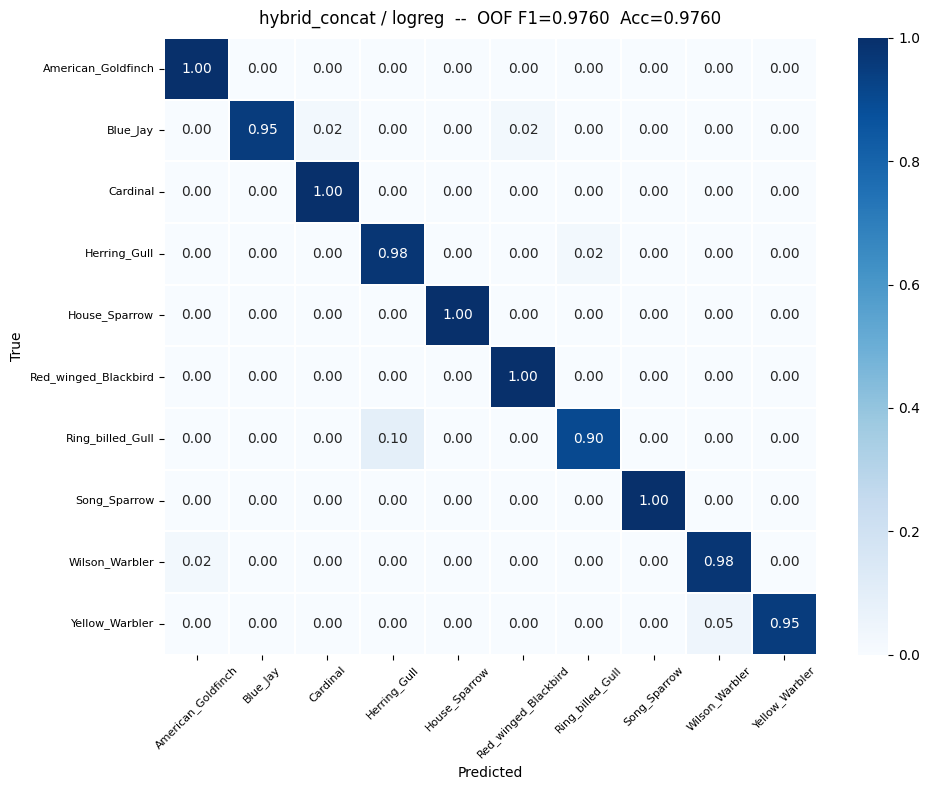


  PER-CLASS F1  (worst -> best)
  Class                               F1   Support
  ---------------------------------------------------
  Ring_billed_Gull                0.9383        42
  Herring_Gull                    0.9425        42
  Wilson_Warbler                  0.9647        42
  Blue_Jay                        0.9756        42
  Yellow_Warbler                  0.9756        42
  Cardinal                        0.9873        39
  American_Goldfinch              0.9882        42
  Red_winged_Blackbird            0.9882        42
  House_Sparrow                   1.0000        42
  Song_Sparrow                    1.0000        42

  Class: Ring_billed_Gull              F1=0.9383  errors=4/42
  Confusion row  (total=42):
    OK  Ring_billed_Gull               38x
    XX  Herring_Gull                    4x



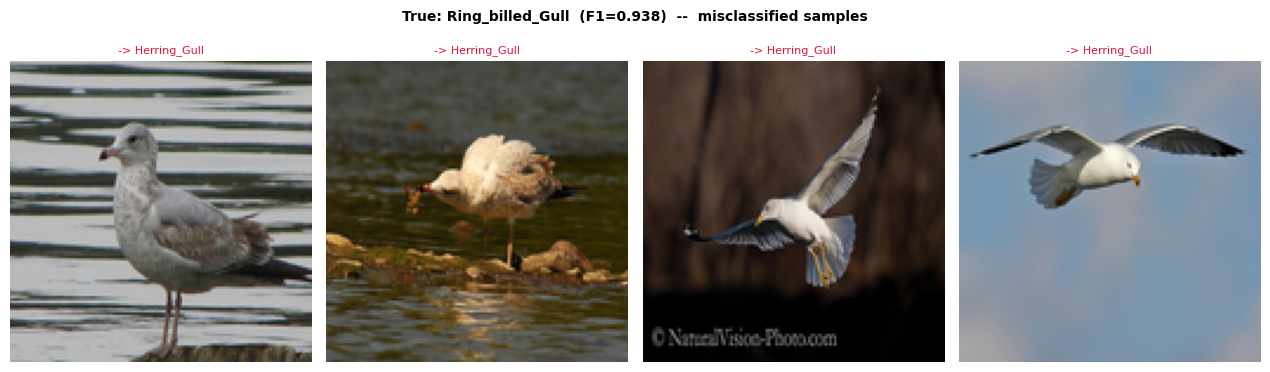


  Class: Herring_Gull                  F1=0.9425  errors=1/42
  Confusion row  (total=42):
    OK  Herring_Gull                   41x
    XX  Ring_billed_Gull                1x



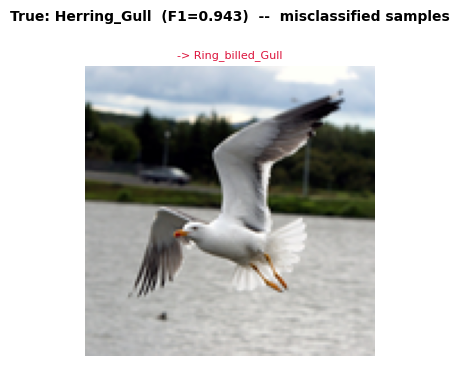


  Class: Wilson_Warbler                F1=0.9647  errors=1/42
  Confusion row  (total=42):
    OK  Wilson_Warbler                 41x
    XX  American_Goldfinch              1x



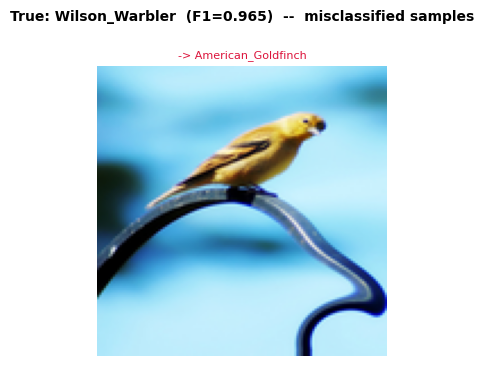


  Class: Blue_Jay                      F1=0.9756  errors=2/42
  Confusion row  (total=42):
    OK  Blue_Jay                       40x
    XX  Red_winged_Blackbird            1x
    XX  Cardinal                        1x



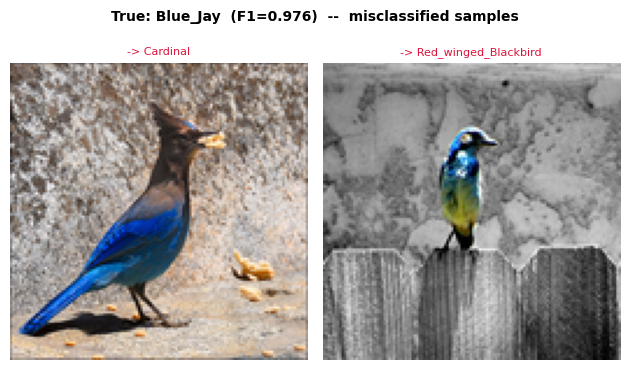


  Class: Yellow_Warbler                F1=0.9756  errors=2/42
  Confusion row  (total=42):
    OK  Yellow_Warbler                 40x
    XX  Wilson_Warbler                  2x



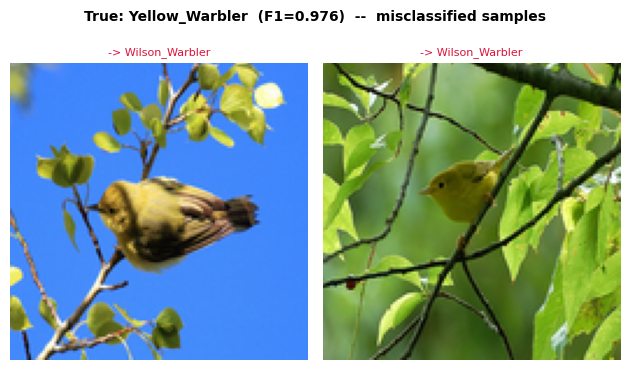


  Class: Cardinal                      F1=0.9873  errors=0/39
  :)  Model got every sample in this class correct!

  Class: American_Goldfinch            F1=0.9882  errors=0/42
  :)  Model got every sample in this class correct!

  Class: Red_winged_Blackbird          F1=0.9882  errors=0/42
  :)  Model got every sample in this class correct!

  Class: House_Sparrow                 F1=1.0000  errors=0/42
  :)  Model got every sample in this class correct!

  Class: Song_Sparrow                  F1=1.0000  errors=0/42
  :)  Model got every sample in this class correct!



In [243]:
# =============================================================================
# ERROR ANALYSIS
# =============================================================================
# Reads oof_pred / all_labels produced by PRE-SUBMISSION VALIDATION.
# Run that cell first, then run this one.

# max misclassified images to show per class
IMAGES_PER_CLASS = 10


# --- prerequisite check ------------------------------------------------------

class_names = [index_to_class[i] for i in sorted(index_to_class)]
n_classes   = len(class_names)
cm          = confusion_matrix(all_labels, oof_pred)
oof_f1      = f1_score(all_labels, oof_pred, average='weighted', zero_division=0)
oof_acc     = accuracy_score(all_labels, oof_pred)


# =============================================================================
# CONFUSION MATRIX
# =============================================================================

cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

# create and plot heatmap
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names,
            ax=ax, vmin=0, vmax=1, linewidths=0.3)

# title
ax.set_title(
    f'{SUBMISSION_MODE} / {SUBMISSION_CLASSIFIER}  --  OOF F1={oof_f1:.4f}  Acc={oof_acc:.4f}',
    pad=10,
)

ax.set_xlabel('Predicted')
ax.set_ylabel('True')
ax.tick_params(axis='x', rotation=45, labelsize=8)
ax.tick_params(axis='y', rotation=0,  labelsize=8)
plt.tight_layout()
plt.show()


# =============================================================================
# PER-CLASS F1 TABLE
# =============================================================================

report        = classification_report(all_labels, oof_pred, target_names=class_names,
                                      output_dict=True, zero_division=0)
class_f1s     = [(cls, report[cls]['f1-score']) for cls in class_names]
class_f1s_sorted = sorted(class_f1s, key=lambda x: x[1])   # worst first

print(f'\n{"="*55}')
print('  PER-CLASS F1  (worst -> best)')
print(f'{"="*55}')
print(f'  {"Class":<28}  {"F1":>8}  {"Support":>8}')
print(f'  {"-"*51}')

for cls, f1_val in class_f1s_sorted:
    supp = int(report[cls]['support'])
    print(f'  {cls:<28}  {f1_val:>8.4f}  {supp:>8}')

print()


# =============================================================================
# MISCLASSIFIED IMAGES PER CLASS  (worst first)
# =============================================================================

for cls, class_f1_val in class_f1s_sorted:

    class_idx  = class_to_index[cls]
    wrong_mask = (all_labels == class_idx) & (oof_pred != class_idx)
    wrong_pos  = np.where(wrong_mask)[0]

    print(f'{"="*78}')
    print(f'  Class: {cls:<28}  F1={class_f1_val:.4f}  '
          f'errors={len(wrong_pos)}/{int(report[cls]["support"])}')
    
    print(f'{"="*78}')

    # no errors
    if len(wrong_pos) == 0:
        print('  :)  Model got every sample in this class correct!\n')
        continue

    # per-class confusion row
    conf_row = cm[class_idx]
    print(f'  Confusion row  (total={conf_row.sum()}):')
    
    for other_idx in np.argsort(conf_row)[::-1]:
        if conf_row[other_idx] == 0:
            continue
        marker = 'OK' if other_idx == class_idx else 'XX'
        print(f'    {marker}  {index_to_class[other_idx]:<28}  {conf_row[other_idx]:>3}x')
    print()

    # image grid
    show_pos = wrong_pos[:IMAGES_PER_CLASS]
    n_show   = len(show_pos)
    n_cols   = min(4, n_show)
    n_rows   = math.ceil(n_show / n_cols)

    # create the plots for the images
    fig_mc, axes_mc = plt.subplots(
        n_rows, n_cols,
        figsize=(3.2 * n_cols, 3.2 * n_rows + 0.7),
    )
    
    # text
    fig_mc.suptitle(
        f'True: {cls}  (F1={class_f1_val:.3f})  --  misclassified samples',
        fontsize=10, fontweight='bold',
    )
    
    # alignment
    axes_flat = np.array(axes_mc).flatten() if n_show > 1 else [axes_mc]

    for ax_img, pos in zip(axes_flat, show_pos):
        pred_cls = index_to_class[oof_pred[pos]]
        
        ax_img.imshow(Image.open(train_image_paths[pos]))

        ax_img.set_title(f'-> {pred_cls}', fontsize=8, color='crimson')
        ax_img.axis('off')

    for ax_img in axes_flat[n_show:]:
        ax_img.axis('off')

    plt.tight_layout()
    plt.show()
    print()
